In [1]:
import importlib
import sys
import os

sys.path.append(os.path.abspath("../"))

from utils.gref_pipeline import georef
from gref_pipeline import config

importlib.reload(georef)
from utils.gref_pipeline.georef import *

In [2]:
transect = load_transect(config.OUTPUT_FOLDER)
transect.list_files()

cube = transect.select_files(
    [
        # "rad_uhi_20241029_115057_1",
        # "rad_uhi_20241029_115057_2",
        # "rad_uhi_20241029_115057_3",
        # "rad_uhi_20241029_115057_4",
        "rad_uhi_20241029_115057_5",
        # "rad_uhi_20241029_115057_6",
    ]
)
cube.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_115057_1  | shape=(1333, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_115057_2  | shape=(1946, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_115057_3  | shape=(2227, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_115057_4  | shape=(2463, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_115057_5  | shape=(2462, 968, 210)  | has_georef=True
 6. rad_uhi_20241029_115057_6  | shape=(155, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)


✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Loaded full cube: (2462, 968, 210) (T × S × B)

=== Combined_output ===
Tracks × Slits: 2462 × 968
RGB coverage: R/G/B finite ratios 1.00/1.00/1.00

📋 File boundaries:
  rad_uhi_20241029_115057_5: tracks 0–2461 (2462)
✅ Loaded full cube: (2462, 968, 210) (T × S × B)

=== Combined_output ===
Tracks × Slits: 2462 × 968
RGB coverage: R/G/B finite ratios 1.00/1.00/1.00

📋 File boundaries:
  rad_uhi_20241029_115057_5: tracks 0–2461 (2462)


In [3]:
cube.apply_illumination_correction_v2()

🔄 Using V2 algorithm (pandas rolling median)
✅ Illumination correction already applied with window=500, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 1 files...
   rad_uhi_20241029_115057_5: window=500, strength=1.0
✅ Loaded illumination correction from disk
   rad_uhi_20241029_115057_5: window=500, strength=1.0
✅ Loaded illumination correction from disk


array([[[2.2304249e+00, 1.6764377e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.0077596e+00, 0.0000000e+00],
        [7.4757171e+00, 8.5974735e-01, 0.0000000e+00, ...,
         0.0000000e+00, 3.0958059e+00, 0.0000000e+00],
        [1.8294926e+00, 2.3438740e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.1090145e+00, 0.0000000e+00],
        ...,
        [1.7213115e+00, 1.4317783e+00, 0.0000000e+00, ...,
         1.0000000e+00, 2.3279436e-02, 3.7040919e-01],
        [5.8812752e+00, 2.0123754e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.4956644e+00, 0.0000000e+00],
        [2.3867478e+00, 1.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.5736811e+01, 4.5105180e-01]],

       [[2.2304249e+00, 7.7452070e-01, 3.9940205e+00, ...,
         0.0000000e+00, 0.0000000e+00, 9.6023534e-05],
        [1.7471981e+00, 0.0000000e+00, 1.2654871e+00, ...,
         0.0000000e+00, 8.5029960e-01, 6.3767982e-01],
        [1.9216584e+00, 0.0000000e+00, 3.0771544e+00, ...,
         0.000

In [4]:
cube.import_rois("./ROIs/057_5_combined.json")
cube.list_rois()

📂 Imported 6 ROIs from ./ROIs/057_5_combined.json

📂 ROI Collection (6 ROIs):
 1. 'dark spots': 358 pixels
     Slit range:  174 - 740
     Track range: 729 - 1416
 2. 'all bombs': 454 pixels
     Slit range:  244 - 880
     Track range: 593 - 1547
 3. 'sediment': 273 pixels
     Slit range:   14 - 870
     Track range: 577 - 1580
 4. 'training_dark': 364 pixels
     Slit range:   24 - 962
     Track range:  23 - 2420
 5. 'training_sediment': 398 pixels
     Slit range:   31 - 924
     Track range:  51 - 2417
 6. 'training_bombs': 201 pixels
     Slit range:  513 - 794
     Track range: 2136 - 2416


In [5]:
training_rois = [
    "training_dark",
    "training_sediment",
    "training_bombs",
]

validation_rois = [
    "sediment",
    "dark spots",
    "all bombs",
]

In [6]:
# STEP 2: Train SVM with cross-validation on pixels OUTSIDE segment
cv_results = cube.train_svm_with_cv(
    training_rois=training_rois,
    segment_start=config.UHI_TRACK_RANGE_5[0],
    segment_end=config.UHI_TRACK_RANGE_5[1],
    wavelength_range=(490, 680),  # ✅ NEW: Only use 500-650nm wavelengths
    cv_folds=5,
    use_corrected=True,
    svm_kernel="rbf",
    optimize_params=True,
    quiet=False,
)

# Print summary
print(f"\n" + "=" * 60)
print(f"📊 CROSS-VALIDATION SUMMARY")
print(f"=" * 60)
print(
    f"Accuracy:  {cv_results['cv_mean_metrics']['accuracy_mean']:.3f} ± {cv_results['cv_mean_metrics']['accuracy_std']:.3f}"
)
print(
    f"Precision: {cv_results['cv_mean_metrics']['precision_mean']:.3f} ± {cv_results['cv_mean_metrics']['precision_std']:.3f}"
)
print(
    f"Recall:    {cv_results['cv_mean_metrics']['recall_mean']:.3f} ± {cv_results['cv_mean_metrics']['recall_std']:.3f}"
)
print(
    f"F1 Score:  {cv_results['cv_mean_metrics']['f1_mean']:.3f} ± {cv_results['cv_mean_metrics']['f1_std']:.3f}"
)

print(f"\n🎯 Best hyperparameters:")
print(f"  C = {cv_results['best_params']['C']}")
print(f"  gamma = {cv_results['best_params']['gamma']}")

print(f"\n📍 Training pixels used:")
for class_name, count in cv_results["training_pixels_per_class"].items():
    print(f"  {class_name}: {count} pixels")

print(f"\n🔍 Pixel filtering:")
print(f"  Kept (outside segment): {cv_results['filtered_pixels_outside']}")
print(f"  Rejected (inside segment): {cv_results['filtered_pixels_inside']}")

🤖 SVM TRAINING WITH CROSS-VALIDATION

� Wavelength filtering:
   Range: 490 - 680 nm
   Wavelengths used: 108 (from 210)

�📦 Datacube shape: (2462, 968, 108)
📏 Using data: corrected
🎯 Segment range: tracks 576 to 1566
📍 Training ROIs: ['training_dark', 'training_sediment', 'training_bombs']

🔍 Filtering ROI pixels...
   training_dark: 364 pixels (rejected 0 inside segment)
   training_sediment: 397 pixels (rejected 1 inside segment)
   training_bombs: 201 pixels (rejected 0 inside segment)

✅ Training data: 962 pixels, 108 wavelengths
   Kept (outside segment): 962
   Rejected (inside segment): 1

🔬 Creating spatial groups for CV...
   Settings: closing_radius=3, min_group_size=20
   training_dark: 364 pixels → 6 groups via connected_components
      dark#A: 119 pixels
      dark#B: 50 pixels
      dark#C: 37 pixels
      dark#D: 29 pixels
      dark#E: 51 pixels
      dark#F: 78 pixels

� Wavelength filtering:
   Range: 490 - 680 nm
   Wavelengths used: 108 (from 210)

�📦 Datacube sha

💡 Interactive mode: Click on the plot to display coordinates


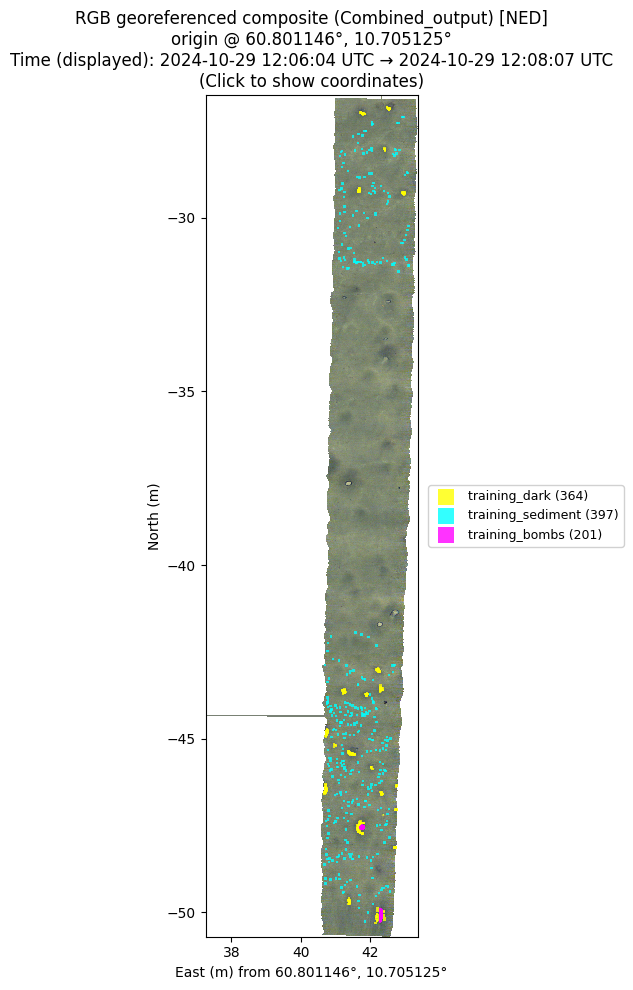

In [7]:
# STEP 3: Visualize FILTERED training ROIs (shows exactly what was used)
%matplotlib inline

cube.plot_georef(
    use_corrected=True,
    figsize=(40, 10),
    roi_collection=cv_results['filtered_training_rois'],  # ✅ Use filtered ROIs!
    roi_marker_size=3,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=40,
)

## STEP 3.5: Visualize Spatial Groups (bomb#1, bomb#2, dark#A, etc.)

This shows how the training ROIs were spatially clustered into groups for CV.

💡 Interactive mode: Click on the plot to display coordinates


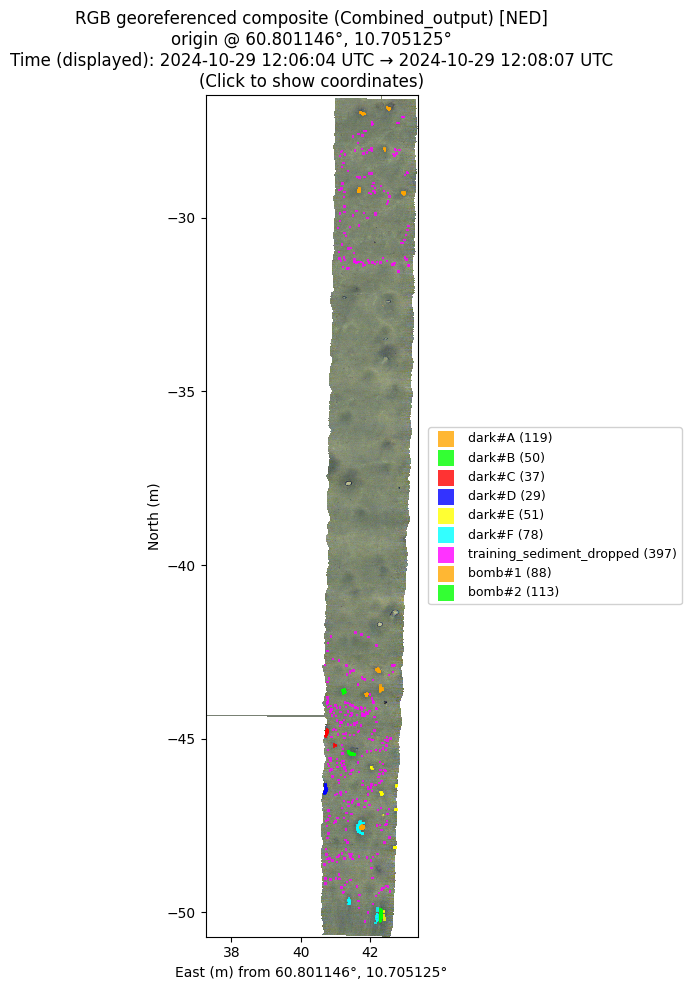


📊 Spatial Groups Created:
   bomb#1: 88 pixels
   bomb#2: 113 pixels
   dark#A: 119 pixels
   dark#B: 50 pixels
   dark#C: 37 pixels
   dark#D: 29 pixels
   dark#E: 51 pixels
   dark#F: 78 pixels
   training_sediment_dropped: 397 pixels


In [8]:
# Plot spatial groups created during training
if (
    "spatial_groups_roi_collection" in cv_results
    and cv_results["spatial_groups_roi_collection"]
):
    cube.plot_georef(
        use_corrected=True,
        figsize=(40, 10),
        roi_collection=cv_results[
            "spatial_groups_roi_collection"
        ],  # 🔥 Spatial groups!
        roi_marker_size=3,
        roi_legend_loc="outside",
        roi_marker_edgewidth=0,
        roi_legend_markersize=40,
    )

    # Print group info
    print("\n📊 Spatial Groups Created:")
    for group_name, pixels in sorted(
        cv_results["spatial_groups_roi_collection"].items()
    ):
        print(f"   {group_name}: {len(pixels)} pixels")
else:
    print(
        "⚠️ No spatial groups found in cv_results. Did you enable use_spatial_groups=True?"
    )

In [9]:
# STEP 4: Classify segment and validate on pixels INSIDE segment
classification_results = cube.classify_segment_with_validation(
    segment_start=config.UHI_TRACK_RANGE_5[0],
    segment_end=config.UHI_TRACK_RANGE_5[1],
    validation_rois=validation_rois,
    validation_class_mapping={
        "sediment": "training_sediment",
        "dark spots": "training_dark",
        "all bombs": "training_bombs",
    },
    use_corrected=True,
    save_to_h5=True,
    dataset_name="svm_classification_validated",
    quiet=False,
)

# Print validation results
if classification_results["validation_metrics"]:
    val_metrics = classification_results["validation_metrics"]

    print(f"\n" + "=" * 60)
    print(f"📈 VALIDATION RESULTS")
    print(f"=" * 60)
    print(f"Overall Accuracy: {val_metrics['accuracy']:.3f}")

    print(f"\n📊 Confusion Matrix:")
    print(f"Classes: {classification_results['class_names']}")
    print(val_metrics["confusion_matrix"])

    print(f"\n📋 Per-Class Metrics:")
    for class_name in classification_results["class_names"]:
        print(f"\n{class_name}:")
        print(f"  Precision: {val_metrics['precision_per_class'][class_name]:.3f}")
        print(f"  Recall:    {val_metrics['recall_per_class'][class_name]:.3f}")
        print(f"  F1 Score:  {val_metrics['f1_per_class'][class_name]:.3f}")
        print(f"  Support:   {val_metrics['support_per_class'][class_name]} pixels")

🎯 SEGMENT CLASSIFICATION WITH VALIDATION

📊 Using wavelength subset: 108 wavelengths

📦 Datacube shape: (2462, 968, 108)
📏 Using data: corrected
🎯 Segment range: tracks 576 to 1566

🔪 Extracting segment...
   Segment shape: (991, 968, 108)

🤖 Classifying 959288 pixels...

📊 Using wavelength subset: 108 wavelengths

📦 Datacube shape: (2462, 968, 108)
📏 Using data: corrected
🎯 Segment range: tracks 576 to 1566

🔪 Extracting segment...
   Segment shape: (991, 968, 108)

🤖 Classifying 959288 pixels...


   Classifying: 100%|█████████████████████████████████| 959288/959288 [13:10<00:00, 1213.51pixels/s]



   ✅ Classification complete in 790.55 seconds

📊 Classification distribution:
   training_bombs: 1369 pixels (0.1%)
   training_dark: 134230 pixels (14.0%)
   training_sediment: 823689 pixels (85.9%)

✅ Validating on ROIs inside segment...
   sediment → training_sediment: 268 validation pixels (rejected 5 outside segment)
   dark spots → training_dark: 358 validation pixels (rejected 0 outside segment)
   all bombs → training_bombs: 454 validation pixels (rejected 0 outside segment)

📈 Validation Results:
   Overall Accuracy: 0.770

   Confusion Matrix:
   Classes: ['training_bombs', 'training_dark', 'training_sediment']
[[208  15 231]
 [  0 358   0]
 [  0   2 266]]

   Per-Class Metrics:
   training_bombs: P=1.000, R=0.458, F1=0.628, Support=454
   training_dark: P=0.955, R=1.000, F1=0.977, Support=358
   training_sediment: P=0.535, R=0.993, F1=0.695, Support=268

💾 Saving classification to H5 files...
   ⚠️  Could not save to rad_uhi_20241029_115057_5: [Errno 11] Unable to synchrono

💡 Interactive mode: Click on the plot to display coordinates


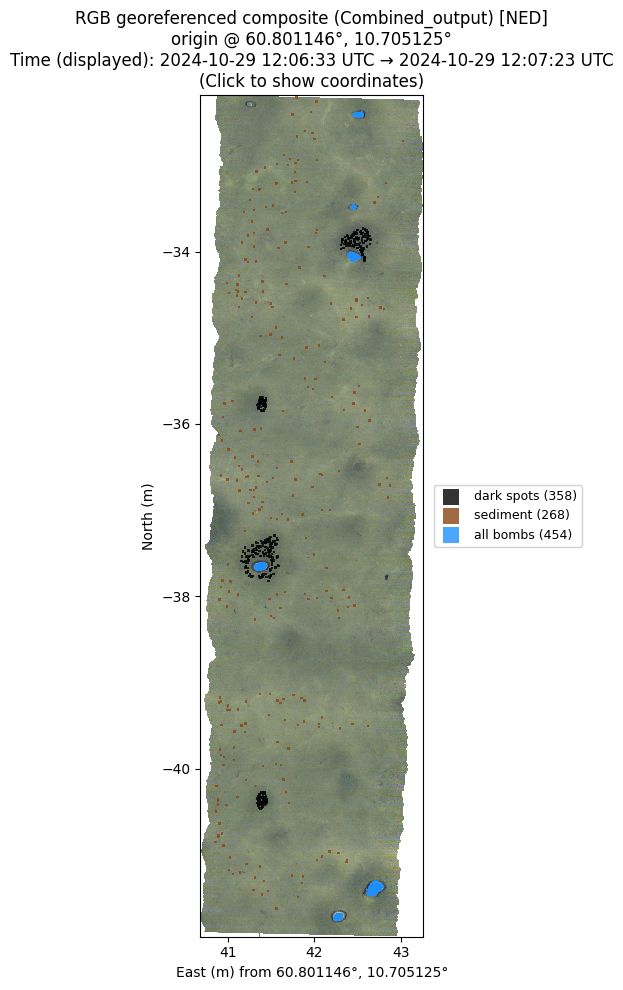

In [10]:
# STEP 5: Visualize FILTERED validation ROIs (shows exactly what was used)
cube.plot_georef(
    use_corrected=True,
    track_start=config.UHI_TRACK_RANGE_5[0],
    track_end=config.UHI_TRACK_RANGE_5[1],
    figsize=(40, 10),
    roi_collection=classification_results[
        "filtered_validation_rois"
    ],  # ✅ Use filtered ROIs!
    roi_marker_size=3,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=40,
)

c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\gref4hsi\final_act\utils\gref_pipeline\georef.py:7278: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(


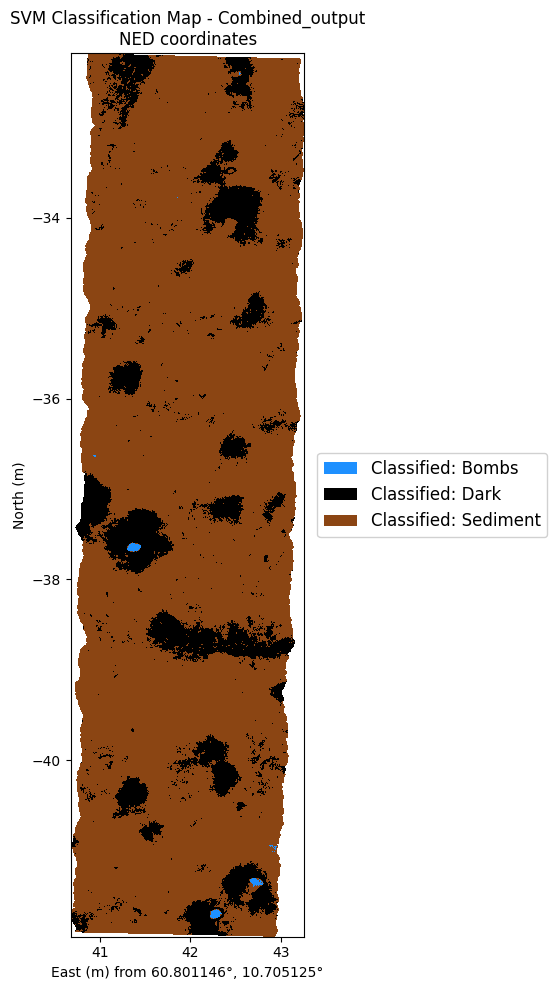

In [11]:
# STEP 6: Plot pure classification map
cube.plot_classification_map(
    coordinate_system="NED", figsize=(40, 10), cmap="tab10", show_legend=True
)

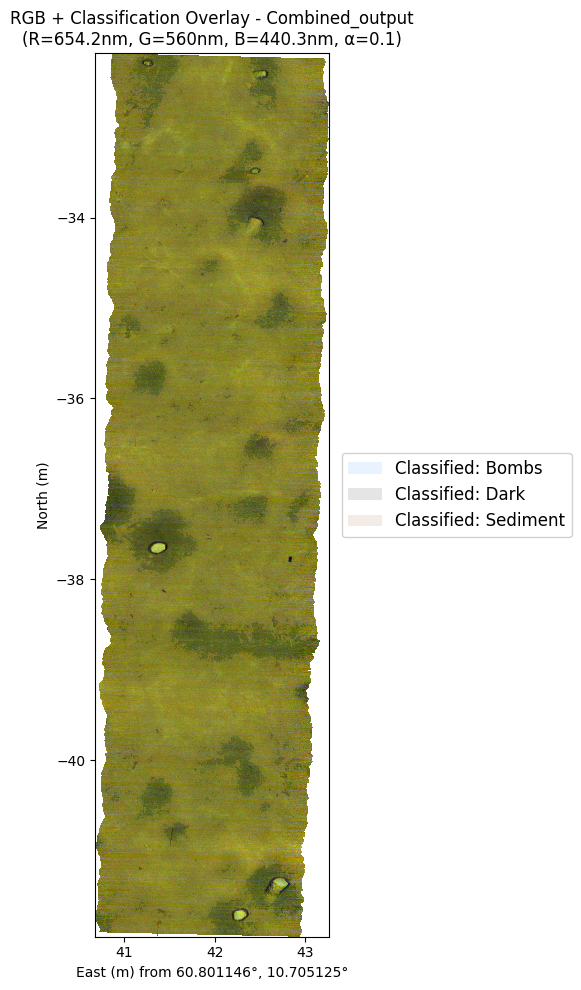

In [12]:
# STEP 7: Plot RGB + classification overlay
cube.plot_classification_overlay(
    coordinate_system="NED",
    use_corrected=True,
    figsize=(40, 10),
    alpha=0.1,  # % transparency
    cmap="tab10",
    show_legend=True,
)